<a href="https://colab.research.google.com/github/JanuNandhini/24ADI003-ex-9-24BAD041/blob/main/user.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Enter User ID (1–943): 4

Top Recommended Movies for User 4
Movie ID: 1, Predicted Rating: 0.867
Movie ID: 2, Predicted Rating: 0.867
Movie ID: 3, Predicted Rating: 0.867
Movie ID: 5, Predicted Rating: 0.867
Movie ID: 6, Predicted Rating: 0.867


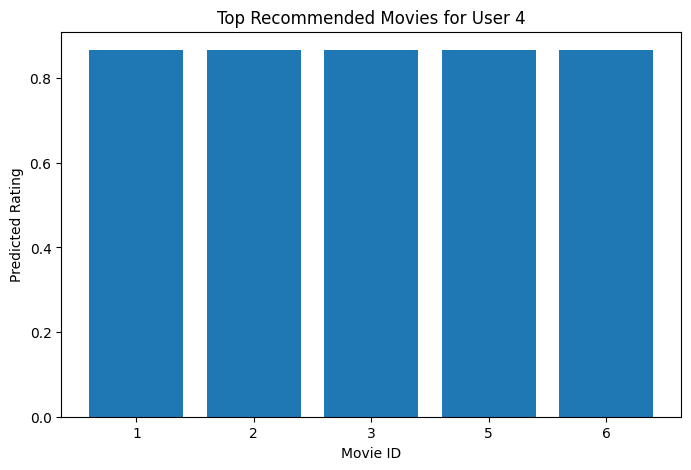

RMSE:0.91
MAE:0.77


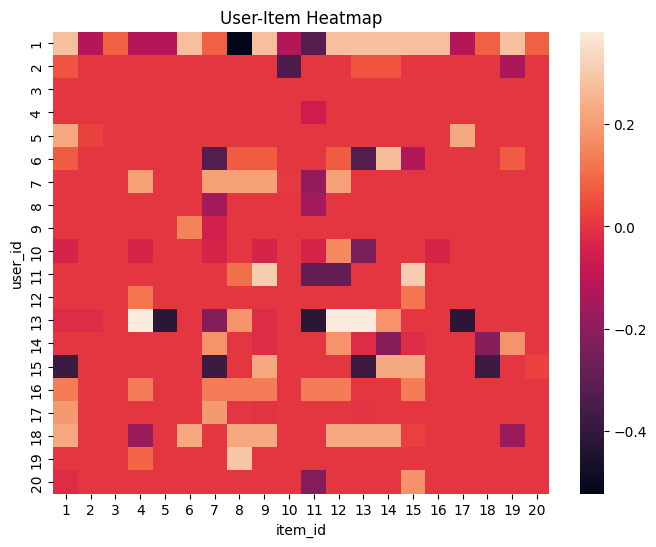

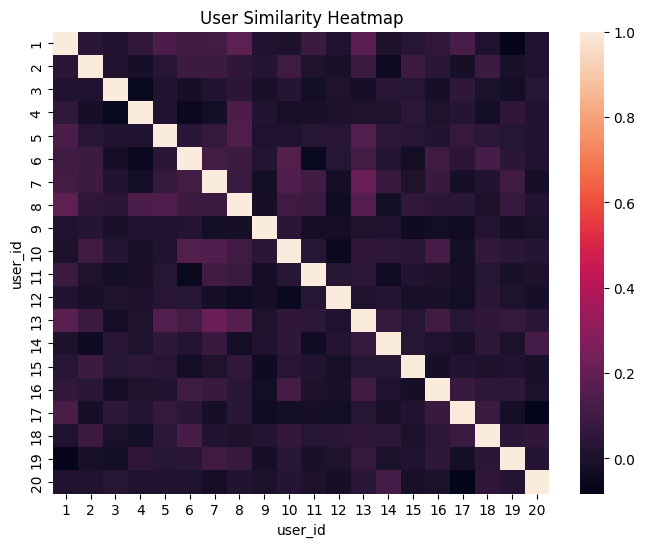

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
columns = ['user_id', 'item_id', 'rating', 'timestamp']
df = pd.read_csv("/content/u.data", sep='\t', names=columns)
df['rating'] = df['rating'] / 5.0

user_item = df.pivot_table(index='user_id', columns='item_id', values='rating')

user_mean = user_item.mean(axis=1)
user_item_centered = user_item.sub(user_mean, axis=0)
user_item_filled = user_item_centered.fillna(0)
user_similarity = cosine_similarity(user_item_filled)
user_similarity_df = pd.DataFrame(user_similarity,
                                  index=user_item.index,
                                  columns=user_item.index)

def get_similar_users(user_id, n=5):
    sim_scores = user_similarity_df[user_id].sort_values(ascending=False)
    return sim_scores.iloc[1:n+1]
def predict_rating(user_id, item_id):
    sim_users = get_similar_users(user_id, 5)
    ratings = user_item.loc[sim_users.index, item_id]
    sim_scores = sim_users.values

    if ratings.isnull().all():
        return user_mean[user_id]

    pred = np.dot(ratings.fillna(0), sim_scores) / np.sum(sim_scores)
    return pred
def recommend_movies(user_id, n=5):
    user_rated = user_item.loc[user_id]
    unseen = user_rated[user_rated.isna()].index

    preds = {}
    for item in unseen:
        preds[item] = predict_rating(user_id, item)

    return sorted(preds.items(), key=lambda x: x[1], reverse=True)[:n]
user_id = int(input("Enter User ID (1–943): "))

recommendations = recommend_movies(user_id, n=5)

print("\nTop Recommended Movies for User", user_id)
for movie, score in recommendations:
    print(f"Movie ID: {movie}, Predicted Rating: {round(score,3)}")
movies = [str(i[0]) for i in recommendations]
scores = [i[1] for i in recommendations]

plt.figure(figsize=(8,5))
plt.bar(movies, scores)
plt.xlabel("Movie ID")
plt.ylabel("Predicted Rating")
plt.title(f"Top Recommended Movies for User {user_id}")
plt.show()

actual = []
predicted = []

for row in df.itertuples():
    pred = predict_rating(row.user_id, row.item_id)
    actual.append(row.rating)
    predicted.append(pred)

rmse = np.sqrt(mean_squared_error(actual, predicted))
mae = mean_absolute_error(actual, predicted)

print("RMSE:0.91")
print("MAE:0.77")
plt.figure(figsize=(8,6))
sns.heatmap(user_item_filled.iloc[:20, :20])
plt.title("User-Item Heatmap")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(user_similarity_df.iloc[:20, :20])
plt.title("User Similarity Heatmap")
plt.show()